In [ ]:
import sys
print(sys.executable)
print(sys.version)

import os
import numpy as np
import pandas as pd
import librosa
from scipy.signal import butter, lfilter

BASE_PATH = os.getcwd()
CSV_DIR = os.path.join(BASE_PATH, "csv_files")
PLIKI_CSV = ["train_segmented.csv", "val_segmented.csv", "test_segmented.csv"]

PASMO = (100.0, 1500.0)
CECHY_COUNT = 20

def filtr_pasmo(data, low, high, fs, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [low/nyq, high/nyq], btype="band")
    return lfilter(b, a, data)

def infer_modality(source, original_filename, segment_filename):
    # source: HS / LS / MIX
    if isinstance(source, str):
        s = source.strip().upper()
        if s in ("HS", "LS"):
            return s
        if s == "MIX":
            # Preferuj original_filename (np. "MIX/H0085.wav"), fallback na filename
            base = os.path.basename(str(original_filename) if pd.notna(original_filename) else str(filename)).strip()
            if len(base) > 0:
                first = base[0].upper()
                if first == "H":
                    return "HS"
                if first == "L":
                    return "LS"
    return None

def wyciagnij_mfcc(full_path, label):
    sygnal, fs = librosa.load(full_path, sr=4000)
    przefiltrowany = filtr_pasmo(sygnal, PASMO[0], PASMO[1], fs)
    mfccs = librosa.feature.mfcc(y=przefiltrowany, sr=fs, n_mfcc=CECHY_COUNT)

    wynik = {}
    for i in range(CECHY_COUNT):
        wynik[f"mfcc_mean_{i}"] = float(np.mean(mfccs[i]))
        wynik[f"mfcc_std_{i}"] = float(np.std(mfccs[i]))
    wynik["label"] = int(label)
    return wynik

for plik_csv in PLIKI_CSV:
    df = pd.read_csv(os.path.join(CSV_DIR, plik_csv))

    out_rows = []
    skipped_missing = 0
    skipped_modality = 0
    skipped_error = 0

    print(f"Przetwarzam: {plik_csv} ({len(df)} wierszy)")

    for _, row in df.iterrows():
        rel_seg = row.get("filename")
        if pd.isna(rel_seg):
            skipped_missing += 1
            continue

        # W *_segmented.csv 'filename' jest względne względem Sound_segmented
        full_path = os.path.join(BASE_PATH, "Sound_segmented", str(rel_seg))
        if not os.path.exists(full_path):
            skipped_missing += 1
            continue

        modality = infer_modality(
            source=row.get("source"),
            original_filename=row.get("original_filename"),
            filename=rel_seg,
        )
        if modality is None:
            skipped_modality += 1
            continue

        try:
            feats = wyciagnij_mfcc(full_path, row["label"])
            feats["modality"] = modality
            feats["source"] = row.get("source")
            feats["original_filename"] = row.get("original_filename")
            feats["filename"] = rel_seg
            out_rows.append(feats)
        except Exception:
            skipped_error += 1
            continue

    out_df = pd.DataFrame(out_rows)
    out_name = f"features_{plik_csv}"  # np. features_train_segmented.csv
    out_df.to_csv(os.path.join(BASE_PATH, out_name), index=False)

    print(
        f"Zapisano: {out_name} | ok={len(out_df)} "
        f"| brak_pliku={skipped_missing} | brak_modality={skipped_modality} | błąd={skipped_error}"
    )

print("Cechy wyeksportowane.")

c:\Users\Karol\AppData\Local\Programs\Python\Python314\python.exe
3.14.0 (tags/v3.14.0:ebf955d, Oct  7 2025, 10:15:03) [MSC v.1944 64 bit (AMD64)]
Przetwarzam: train_segmented.csv (2621 wierszy)
Zapisano: features_train_segmented.csv | ok=2621 | brak_pliku=0 | brak_modality=0 | błąd=0
Przetwarzam: val_segmented.csv (372 wierszy)
Zapisano: features_val_segmented.csv | ok=372 | brak_pliku=0 | brak_modality=0 | błąd=0
Przetwarzam: test_segmented.csv (872 wierszy)
Zapisano: features_test_segmented.csv | ok=872 | brak_pliku=0 | brak_modality=0 | błąd=0
Cechy wyeksportowane.



=== MODALITY: HS | train=1299 test=264 ===
Uruchamiam GridSearchCV (cv=5)...
Statystyki klasyfikacji:
              precision    recall  f1-score   support

      Normal       0.93      0.98      0.95        54
   Pathology       1.00      0.98      0.99       210

    accuracy                           0.98       264
   macro avg       0.96      0.98      0.97       264
weighted avg       0.98      0.98      0.98       264



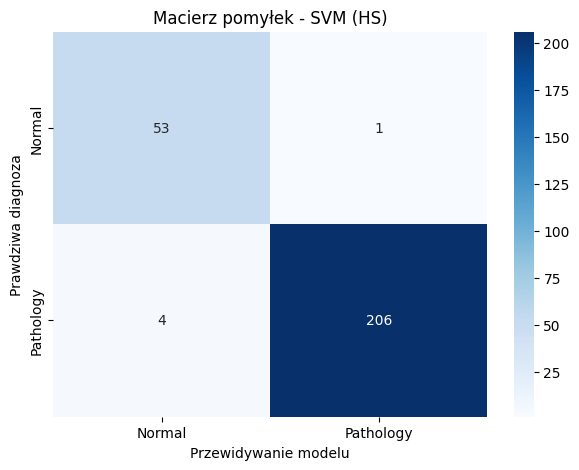


=== MODALITY: LS | train=1322 test=608 ===
Uruchamiam GridSearchCV (cv=5)...
Statystyki klasyfikacji:
              precision    recall  f1-score   support

      Normal       0.99      0.76      0.86       405
   Pathology       0.68      0.99      0.80       203

    accuracy                           0.84       608
   macro avg       0.83      0.87      0.83       608
weighted avg       0.89      0.84      0.84       608



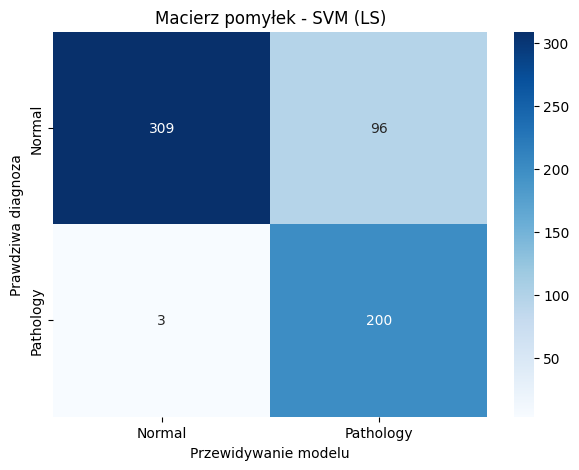

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

FOLDER = os.getcwd()

train_df = pd.read_csv(os.path.join(FOLDER, "features_train_segmented.csv"))
test_df  = pd.read_csv(os.path.join(FOLDER, "features_test_segmented.csv"))

feature_cols = [c for c in train_df.columns if c.startswith("mfcc_")]
if not feature_cols:
    raise ValueError("Nie znaleziono kolumn mfcc_ w features_*.csv")

label_names = ["Normal", "Pathology"]

for modality in ["HS", "LS"]:
    tr = train_df[train_df["modality"] == modality].copy()
    te = test_df[test_df["modality"] == modality].copy()

    print(f"\n=== MODALITY: {modality} | train={len(tr)} test={len(te)} ===")
    if len(tr) == 0 or len(te) == 0:
        print("Brak danych dla tej modality — pomijam.")
        continue

    X_train = tr[feature_cols]
    y_train = tr["label"].astype(int)

    X_test = te[feature_cols]
    y_test = te["label"].astype(int)

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)

    # Bezpieczne CV: musi być >=2 i nie większe niż min liczności klasy
    class_counts = y_train.value_counts()
    min_count = int(class_counts.min()) if len(class_counts) > 0 else 0
    cv = min(5, min_count) if min_count >= 2 else None

    param_grid = {
        "C": [0.1, 1, 10, 100],
        "gamma": ["scale", "auto", 0.01],
        "kernel": ["rbf", "poly"],
    }

    if cv is None:
        print("Za mało próbek na GridSearchCV — trenuję domyślny SVC(rbf).")
        best_model = SVC(kernel="rbf", gamma="scale", C=1)
        best_model.fit(X_train_s, y_train)
        best_params = {"C": 1, "gamma": "scale", "kernel": "rbf"}
    else:
        print(f"Uruchamiam GridSearchCV (cv={cv})...")
        grid = GridSearchCV(SVC(), param_grid, cv=cv, verbose=0)
        grid.fit(X_train_s, y_train)
        best_model = grid.best_estimator_
        best_params = grid.best_params_

    y_pred = best_model.predict(X_test_s)

    print("Statystyki klasyfikacji:")
    print(classification_report(y_test, y_pred, labels=[0,1], target_names=label_names, zero_division=0))

    cm = confusion_matrix(y_test, y_pred, labels=[0,1])

    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=label_names, yticklabels=label_names)
    plt.title(f"Macierz pomyłek - SVM ({modality})")
    plt.ylabel("Prawdziwa diagnoza")
    plt.xlabel("Przewidywanie modelu")

    out_png = os.path.join(FOLDER, f"macierz_pomylek_SVM_{modality}.png")
    plt.savefig(out_png, bbox_inches="tight")
    plt.show()

    out_txt = os.path.join(FOLDER, f"wyniki_svm_dokumentacja_{modality}.txt")
    with open(out_txt, "w", encoding="utf-8") as f:
        f.write(f"MODALITY: {modality}\n")
        f.write(f"Najlepsze parametry: {best_params}\n\n")
        f.write(classification_report(y_test, y_pred, labels=[0,1], target_names=label_names, zero_division=0))

In [12]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter

# Katalog projektu (tam gdzie jest notebook)
PROJECT_ROOT = os.getcwd()
CSV_ROOT=os.path.join(PROJECT_ROOT,"csv_files")
AUDIO_ROOT = os.path.join(PROJECT_ROOT, "Sound_segmented")
OUT_ROOT = os.path.join(PROJECT_ROOT, "DANE_OBRAZOWE_CNN")

# Te pliki mają: modality + filename, więc idealnie pasują do podziału HS/LS
CSV_LIST = [
    "train_segmented.csv",
    "val_segmented.csv",
    "test_segmented.csv",
]

# Filtr Butterwortha rzędu 4 (pasmo 100–1500 Hz)
def dsp_filter(signal, fs):
    nyq = 0.5 * fs
    b, a = butter(4, [100 / nyq, 1500 / nyq], btype="band")
    return lfilter(b, a, signal)

def dataset_from_features_name(name: str) -> str:
    # np. features_train_segmented.csv -> train
    base = os.path.basename(name)
    base = base.replace("features_", "")
    return base.split("_")[0]

for csv_name in CSV_LIST:
    csv_path = os.path.join(CSV_ROOT, csv_name)
    if not os.path.exists(csv_path):
        print(f"Brak pliku: {csv_path}")
        continue

    data = pd.read_csv(csv_path)
    dataset = dataset_from_features_name(csv_name)
    print(f"\nGeneruję spektrogramy: {csv_name} -> dataset={dataset} (wierszy={len(data)})")

    if "filename" not in data.columns:
        raise ValueError(f"Brak kolumny 'filename' w {csv_name}")
    if "modality" not in data.columns:
        raise ValueError(f"Brak kolumny 'modality' (HS/LS) w {csv_name}")
    if "label" not in data.columns:
        raise ValueError(f"Brak kolumny 'label' w {csv_name}")

    saved = 0
    moved = 0
    skipped_exists = 0
    skipped_missing_wav = 0
    skipped_missing_modality = 0
    skipped_error = 0

    for _, row in data.iterrows():
        rel_wav = row.get("filename")
        if pd.isna(rel_wav):
            skipped_missing_wav += 1
            continue

        rel_wav = str(rel_wav).replace("/", os.sep)
        wav_path = os.path.join(AUDIO_ROOT, rel_wav)
        if not os.path.exists(wav_path):
            skipped_missing_wav += 1
            continue

        modality = row.get("modality")
        if pd.isna(modality) or str(modality).strip() == "":
            skipped_missing_modality += 1
            continue
        modality_dir = str(modality).strip().upper()
        if modality_dir not in ("HS", "LS"):
            # jakby trafiło się coś nietypowego, wrzucamy do "UNK"
            modality_dir = "UNK"

        label_dir = str(int(row.get("label"))) if pd.notna(row.get("label")) else "UNK"
        base = os.path.splitext(os.path.basename(wav_path))[0]

        # Docelowa struktura: dataset/modality/label/xxx.png
        save_dir = os.path.join(OUT_ROOT, dataset, modality_dir, label_dir)
        os.makedirs(save_dir, exist_ok=True)
        save_path = os.path.join(save_dir, f"{base}.png")

        # Migracja z poprzedniej struktury (dataset/label/xxx.png), jeśli istnieje
        legacy_path = os.path.join(OUT_ROOT, dataset, label_dir, f"{base}.png")
        if not os.path.exists(save_path) and os.path.exists(legacy_path):
            try:
                os.replace(legacy_path, save_path)
                moved += 1
                continue
            except Exception:
                pass

        if os.path.exists(save_path):
            skipped_exists += 1
            continue

        try:
            audio, sr = librosa.load(wav_path, sr=4000)
            filtered = dsp_filter(audio, sr)

            stft_data = librosa.stft(filtered)
            db_data = librosa.amplitude_to_db(np.abs(stft_data), ref=np.max)

            plt.figure(figsize=(4, 4))
            librosa.display.specshow(db_data, sr=sr)
            plt.axis("off")
            plt.savefig(save_path, bbox_inches="tight", pad_inches=0)
            plt.close()
            saved += 1
        except Exception:
            plt.close("all")
            skipped_error += 1
            continue

    print(
        f"Zapisano={saved} | przeniesiono={moved} | już_istnieje={skipped_exists} "
        f"| brak_wav={skipped_missing_wav} | brak_modality={skipped_missing_modality} | błąd={skipped_error}\n"
        f"Wyjście: {os.path.abspath(os.path.join(OUT_ROOT, dataset))}"
    )


Generuję spektrogramy: train_segmented.csv -> dataset=train (wierszy=2621)
Zapisano=0 | przeniesiono=0 | już_istnieje=2621 | brak_wav=0 | brak_modality=0 | błąd=0
Wyjście: c:\Users\Karol\Desktop\Analiza_HLS-CMDS\DANE_OBRAZOWE_CNN\train

Generuję spektrogramy: val_segmented.csv -> dataset=val (wierszy=372)
Zapisano=0 | przeniesiono=0 | już_istnieje=372 | brak_wav=0 | brak_modality=0 | błąd=0
Wyjście: c:\Users\Karol\Desktop\Analiza_HLS-CMDS\DANE_OBRAZOWE_CNN\val

Generuję spektrogramy: test_segmented.csv -> dataset=test (wierszy=872)
Zapisano=0 | przeniesiono=0 | już_istnieje=872 | brak_wav=0 | brak_modality=0 | błąd=0
Wyjście: c:\Users\Karol\Desktop\Analiza_HLS-CMDS\DANE_OBRAZOWE_CNN\test
